In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lxml

In [51]:
df = pd.read_csv('serhed.csv')
df

,Year,Unnamed: 1,Sərhəd-buraxılış məntəqələrindən keçən şəxslərin ümumi ayı (nəfər),Azərbaycan vətəndaşları (nəfər),Əcnəbilər və vətəndaşlığı olmayan şəxslər (nəfər),Ölkə ərazisinə daxil olanların sayı (nəfər),Azərbaycan vətəndaşları (nəfər).1,Əcnəbilər və vətəndaşlığı olmayan şəxslər (nəfər).1,Ölkə ərazisini tərk edənlərin sayı (nəfər),Azərbaycan vətəndaşları (nəfər).2,Əcnəbilər və vətəndaşlığı olmayan şəxslər (nəfər).2
0,2024,NaN,9544889.0,4297228.0,5247661.0,4764969.0,2138290.0,2626679.0,4779920.0,2158938.0,2620982.0
1,2023,NaN,7860434.0,3691080.0,4169354.0,3908128.0,1822338.0,2085790.0,3952306.0,1868742.0,2083564.0
2,2022,NaN,6131596.0,2964098.0,3167498.0,3076889.0,1474626.0,1602263.0,3054707.0,1489472.0,1565235.0
3,2021,NaN,3432329.0,1882363.0,1549966.0,1699663.0,907912.0,791751.0,1732666.0,974451.0,758215.0
4,2020,NaN,4028356.0,2384041.0,1644315.0,2015136.0,1219414.0,795722.0,2013220.0,1164627.0,848593.0
5,2019,NaN,17464306.0,11130009.0,6334297.0,8732696.0,5562325.0,3170371.0,8731610.0,5567684.0,3163926.0
6,2018,NaN,15504298.0,9799294.0,5705004.0,7740808.0,4891216.0,2849592.0,7763490.0,4908078.0,2855412.0
7,2017,NaN,13563155.0,8174199.0,5388956.0,6762008.0,4065263.0,2696745.0,6801147.0,4108936.0,2692211.0
8,2016,NaN,13000804.0,8502396.0,4498408.0,6469300.0,4220527.0,2248773.0,6531504.0,4281869.0,2249635.0
9,2015,NaN,12192040.0,8165744.0,4026296.0,6076120.0,4069944.0,2006176.0,6115920.0,4095800.0,2020120.0


In [52]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [53]:
df.columns = ['Year', 'Total', 'Az_Vat_Total', 'Foreigners_Total', 
              'In_Total', 'In_Az', 'In_Foreigners', 
              'Out_Total', 'Out_Az', 'Out_Foreigners']

In [54]:
df.sort_values('Year')

,Year,Total,Az_Vat_Total,Foreigners_Total,In_Total,In_Az,In_Foreigners,Out_Total,Out_Az,Out_Foreigners
21,2003,4927132.0,2844394.0,2082738.0,2484539.0,1446549.0,1037990.0,2442593.0,1397845.0,1044748.0
20,2004,5528570.0,3052023.0,2476547.0,2857905.0,1578527.0,1279378.0,2670665.0,1473496.0,1197169.0
19,2005,6247237.0,3703408.0,2543829.0,3155786.0,1873643.0,1282143.0,3091451.0,1829765.0,1261686.0
18,2006,6096490.0,3575951.0,2520539.0,3001984.0,1740023.0,1261961.0,3094506.0,1835928.0,1258578.0
17,2007,5874533.0,3231641.0,2642892.0,2932994.0,1600293.0,1332701.0,2941539.0,1631348.0,1310191.0
16,2008,8041933.0,4259851.0,3782082.0,3996418.0,2097479.0,1898939.0,4045515.0,2162372.0,1883143.0
15,2009,8345355.0,4690703.0,3654652.0,4158595.0,2328228.0,1830367.0,4186760.0,2362475.0,1824285.0
14,2010,10210332.0,6291743.0,3918589.0,5079043.0,3116137.0,1962906.0,5131289.0,3175606.0,1955683.0
13,2011,11504273.0,7049768.0,4454505.0,5738677.0,3499536.0,2239141.0,5765596.0,3550232.0,2215364.0
12,2012,12678962.0,7716911.0,4962051.0,6326577.0,3842529.0,2484048.0,6352385.0,3874382.0,2478003.0


In [55]:
df['Year'] = df['Year'].astype(int)

In [56]:
cols_to_convert = df.columns.drop('Year')
df[cols_to_convert] = df[cols_to_convert].astype(int)

In [57]:
df[df['Total'] > 15000000]

,Year,Total,Az_Vat_Total,Foreigners_Total,In_Total,In_Az,In_Foreigners,Out_Total,Out_Az,Out_Foreigners
5,2019,17464306,11130009,6334297,8732696,5562325,3170371,8731610,5567684,3163926
6,2018,15504298,9799294,5705004,7740808,4891216,2849592,7763490,4908078,2855412


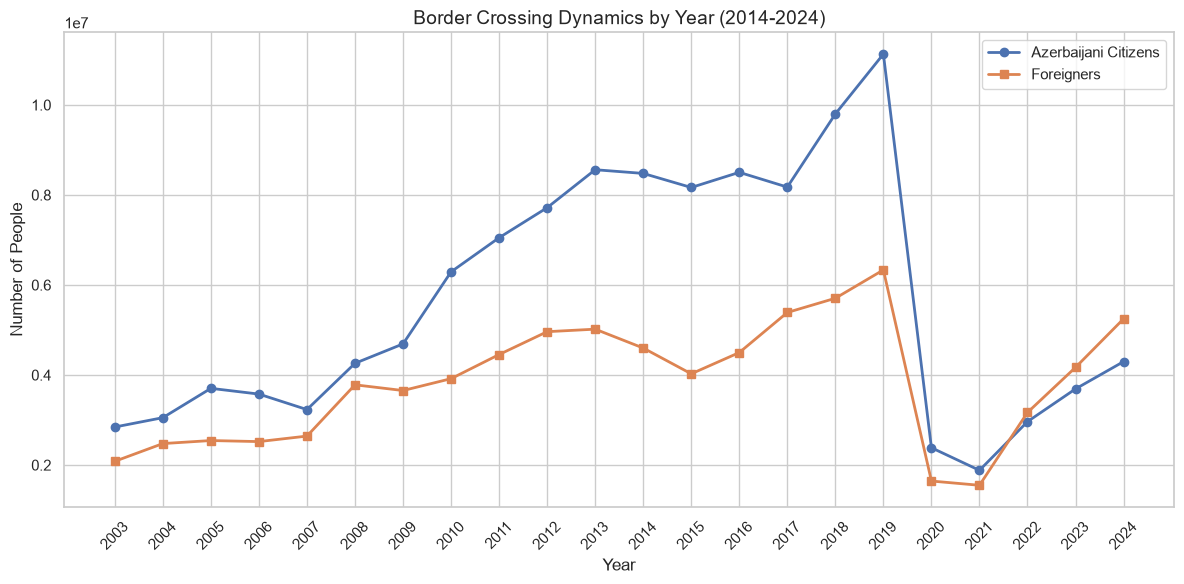

In [58]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plt.plot(df['Year'], df['Az_Vat_Total'], marker='o', label='Azerbaijani Citizens', linewidth=2)
plt.plot(df['Year'], df['Foreigners_Total'], marker='s', label='Foreigners', linewidth=2)

plt.title('Border Crossing Dynamics by Year (2014-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend()

plt.xticks(df['Year'], rotation=45)
plt.tight_layout()

plt.show()

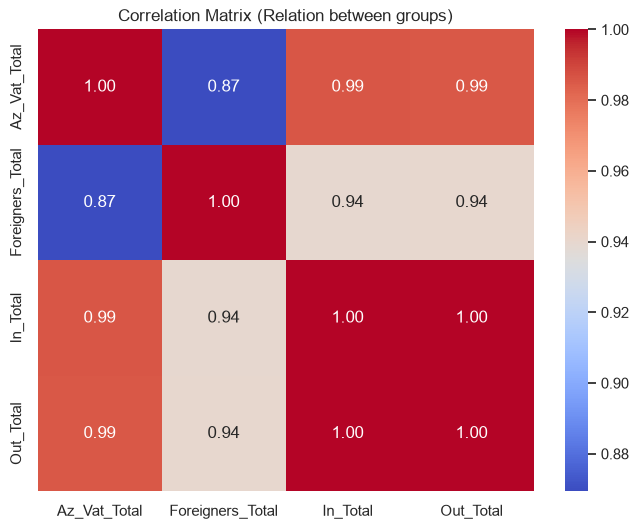

In [59]:
corr_matrix = df[['Az_Vat_Total', 'Foreigners_Total', 'In_Total', 'Out_Total']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Relation between groups)')
plt.show()

In [60]:
corr_matrix.min()

Az_Vat_Total        0.869331
Foreigners_Total    0.869331
In_Total            0.939510
Out_Total           0.940062
dtype: float64

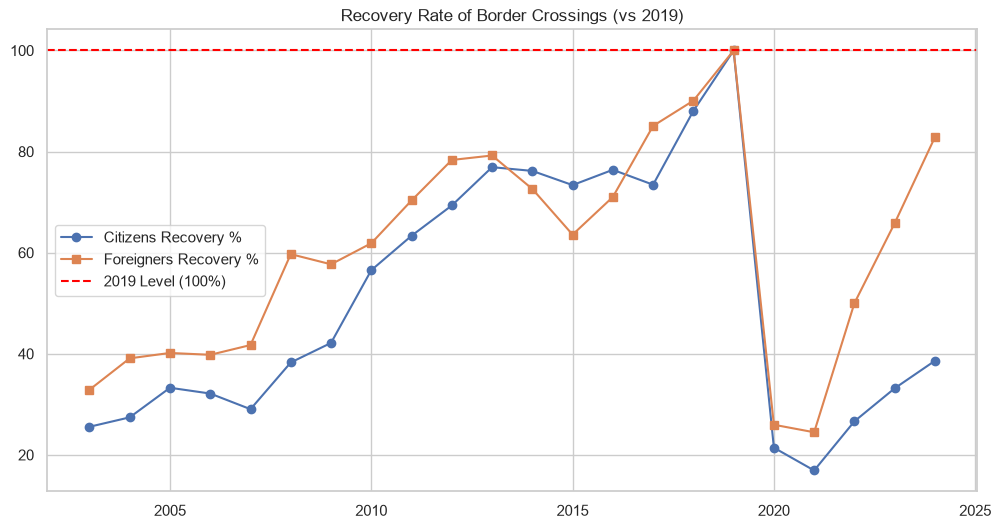

In [61]:
# 2019-cu ili bazis (100%) kimi götürək ki, bərpa faizini hesablayaq
base_year = 2019
df['Az_Recovery'] = (df['Az_Vat_Total'] / df.loc[df['Year'] == base_year, 'Az_Vat_Total'].values[0]) * 100
df['For_Recovery'] = (df['Foreigners_Total'] / df.loc[df['Year'] == base_year, 'Foreigners_Total'].values[0]) * 100

plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['Az_Recovery'], label='Citizens Recovery %', marker='o')
plt.plot(df['Year'], df['For_Recovery'], label='Foreigners Recovery %', marker='s')

plt.axhline(100, color='red', linestyle='--', label='2019 Level (100%)')
plt.title('Recovery Rate of Border Crossings (vs 2019)')
plt.legend()
plt.show()

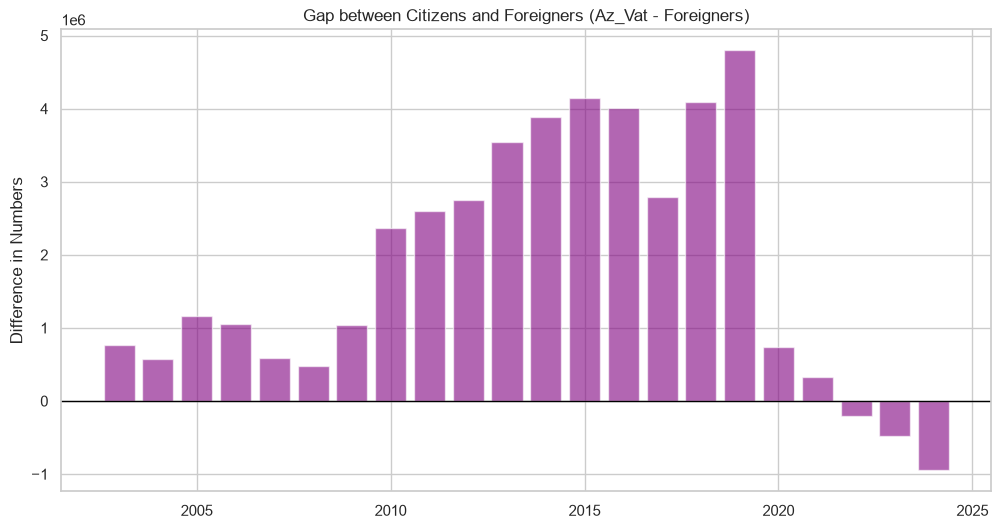

In [62]:
# Hər il üçün aradakı fərq
df['Gap'] = df['Az_Vat_Total'] - df['Foreigners_Total']

plt.figure(figsize=(12, 6))
plt.bar(df['Year'], df['Gap'], color='purple', alpha=0.6)
plt.title('Gap between Citizens and Foreigners (Az_Vat - Foreigners)')
plt.ylabel('Difference in Numbers')
plt.axhline(0, color='black', linewidth=1)
plt.show()

In [63]:
#Pozitiv Fərq (2003–2019): Uzun illər ərzində Gap müsbət olub. Bu o deməkdir ki, Azərbaycan vətəndaşlarının sərhəd keçidlərinin sayı əcnəbilərin sayından daim çox olub. Bu, vətəndaşların miqrasiya, biznes və ya turizm məqsədli hərəkətliliyinin əcnəbilərin gəlişindən daha yüksək olduğunu göstərir.

#Kəskin Eniş (2020): Pandemiya ilə bağlı bütün dünyada olduğu kimi, kəskin eniş müşahidə olunur.

#Qızıl Kəsişmə (2021-2022): Qrafikin ən vacib nöqtəsi budur. Xətt 0-dan aşağı düşür (mənfi ərazi). Bu o deməkdir ki, tarixdə ilk dəfə olaraq ölkəyə gələn əcnəbilərin sayı, xaricə gedən vətəndaşların sayını üstələyib.

#Davamlı Trend (2023-2024): Mənfi fərqin dərinləşməsi (barların aşağı uzanması) göstərir ki, bu artıq bir "təsadüf" deyil, yeni bir reallıqdır. Ölkənin turizm potensialı və ya sərhəd açılışları əcnəbilərin gəlişini daha çox stimullaşdırır.

######################################################################

#Positive Gap (2003–2019): The Gap has been positive for many years. This means that the number of border crossings by Azerbaijani citizens has always been higher than the number of foreigners. This indicates that the mobility of citizens for migration, business or tourism purposes is higher than the arrivals of foreigners.

#Sharp Decline (2020): There is a sharp decline, as is the case all over the world, due to the pandemic.

#Golden Crossing (2021-2022): This is the most important point on the graph. The line drops below 0 (negative territory). This means that for the first time in history, the number of foreigners arriving in the country has exceeded the number of citizens leaving abroad.

#Continuous Trend (2023-2024): The deepening of the negative gap (the bars extending downwards) shows that this is no longer a "coincidence", but a new reality. The country's tourism potential or border openings further stimulate the arrival of foreigners.